## **Evaluación de la Transferencia de Aprendizaje**

Para comprobar la capacidad de generalización y transferencia de conocimiento que presentan los modelos (intra-dominio, unimodales, bimodales, y modelo sobre corpus unificado), se realiza en este notebook una evaluación de la transferencia de aprendizaje, que se dividide en 3 partes:

1. **Evaluación cruzada de los modelos intra-dominio**: Cada uno de los modelos intra-dominio se evalúan con el otro conjunto de datos completo, comprobando la transferencia de aprendizaje de los mismos.

2. **Evaluación frente a un tercer corpus (MSP-Improv)** del modelo final, los baselines unimodales, bimodales e intra-dominio. Todos estos modelos se enfrentan al dataset completo (**650 muestras**) de **MSP-Improv** (dataset independiente nunca antes visto por los modelos).

3. **Evaluación cruzada entre dominios de la arquitectura multimodal final**. Para comprobar la capacidad de generalización y transferencia de aprendizaje real del modelo final, se realiza una evaluación cruzada entre dominios. Esto consiste en rotar iterativamente los conjuntos de datos: con la misma arquitectura del modelo obtenido para MELD e IEMOCAP (fijando la misma configuración e hiperparámetros óptimos), se entrena este modelo desde cero rotando por las distintas combinaciones de datasets: MELD e IEMOCAP ya lo tenemos, falta MELD y MSP-IMPROV / IEMOCAP y MSP-IMPROV. Tras esto, estos modelos obtenidos se evalúan sobre el dataset restante, que se ha mantenido completamente invisible durante todo el entrenamiento. Se reporta finalmente el promedio de las métricas obtenidas de las distintas iteraciones en test. 
Al ir alternando el corpus excluido en distintas iteraciones, se aísla el rendimiento del sistema de los sesgos ambientales, acústicos o de guion presentes a una base de datos específica. De esta forma, se demuestra empíricamente si el modelo es capaz de extraer representaciones universales del estrés y transferir el conocimiento aprendido a entornos e individuos del mundo real totalmente nuevos.

In [1]:
import subprocess
import os
import torch
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = os.path.expanduser('/workspace')
csv_path = os.path.join(BASE_DIR, 'MSP-Improv_clean.csv')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno de ejecución configurado en: {device}")

Entorno de ejecución configurado en: cuda


In [2]:
def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

----
## **1. Evaluación cruzada de los modelos intra-dominio**

* **Modelo entrenado sobre MELD evaluado en el dataset de IEMOCAP**:

In [4]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--transfer_learning IEMOCAP ") ##########
                        
subprocess.run(comando, shell=True)

100%|██████████| 7515/7515 [00:35<00:00, 209.32it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.56 ms / muestra
ROC-AUC Score: 0.6834
F1 Macro: 0.5158
F1 Weighted: 0.5672
Accuracy (en %): 64.62%
Balanced Accuracy (en %): 56.35%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --transfer_learning IEMOCAP ', returncode=0)

* **Modelo entrenado sobre IEMOCAP evaluado en el dataset de MELD**:

In [5]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning MELD ") #######
                        
subprocess.run(comando, shell=True)

100%|██████████| 13704/13704 [01:02<00:00, 219.12it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.37 ms / muestra
ROC-AUC Score: 0.5658
F1 Macro: 0.5268
F1 Weighted: 0.7560
Accuracy (en %): 74.50%
Balanced Accuracy (en %): 53.06%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --transfer_learning MELD ', returncode=0)

----
## **2. Evaluación frente a un tercer corpus (MSP-Improv)**

### **1. Baselines Unimodales**

* **ResNet**:
    * **Ventana**: 32 frames
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 256, `hidden_mlp` = 64
        * **Dropout**: 0.3
        * **Learning Rate**: 1e-05

100%|██████████| 650/650 [00:01<00:00, 536.94it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 5,396,481
Parámetros Entrenables: 5,396,481
Tiempo medio de Inferencia: 0.82 ms / muestra
ROC-AUC Score: 0.5795
F1 Macro: 0.4367
F1 Weighted: 0.6178
Accuracy (en %): 70.31%
Balanced Accuracy (en %): 48.82%


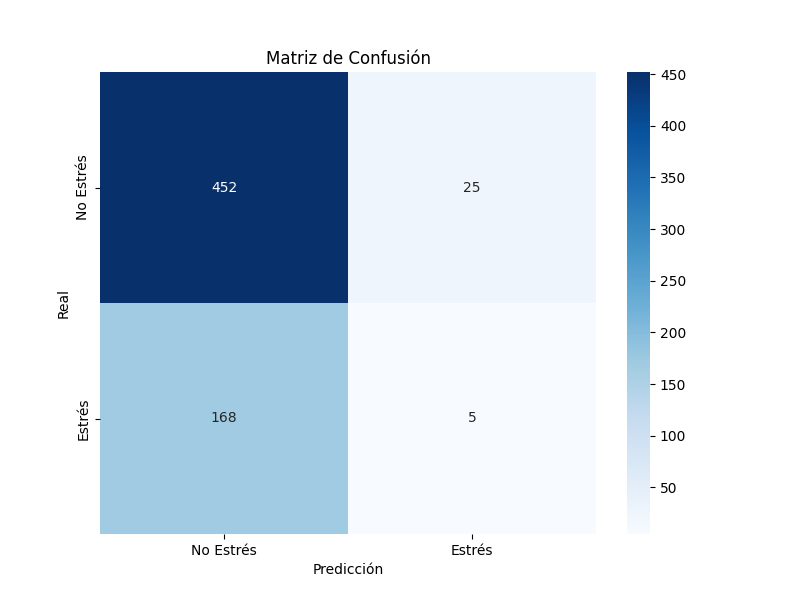

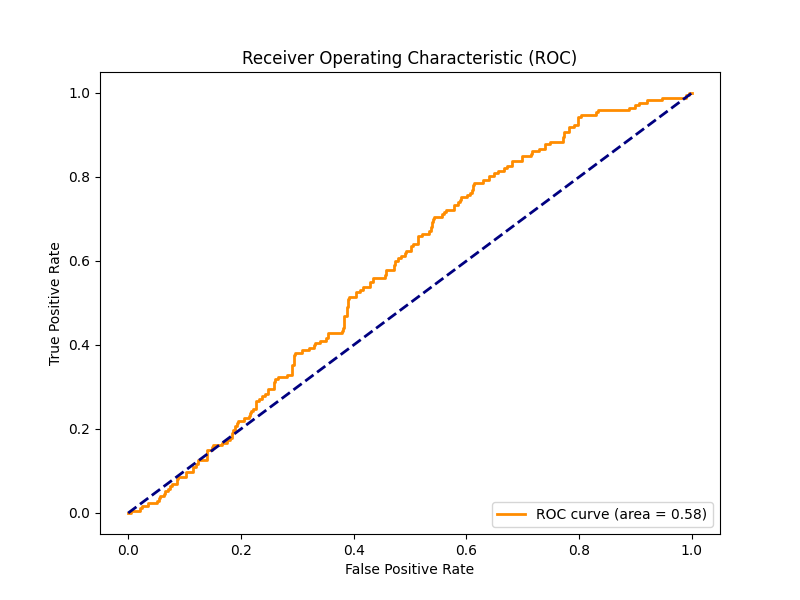

In [3]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--video resnet "
        f"--video_frames 32 "
        f"--proj_dim 256 "
        f"--hidden_mlp 64 "
        f"--dropout 0.3 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_VIDEO_resnet_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_VIDEO_resnet_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Wav2Vec 2.0**:
    * **Ventana**: 7 segundos
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 512, `hidden_mlp` = 128
        * **Dropout**: 0.3
        * **Learning Rate**: 0.0001

100%|██████████| 650/650 [00:02<00:00, 218.11it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 2,956,289
Parámetros Entrenables: 2,956,289
Tiempo medio de Inferencia: 3.07 ms / muestra
ROC-AUC Score: 0.5153
F1 Macro: 0.4227
F1 Weighted: 0.6204
Accuracy (en %): 73.23%
Balanced Accuracy (en %): 49.90%


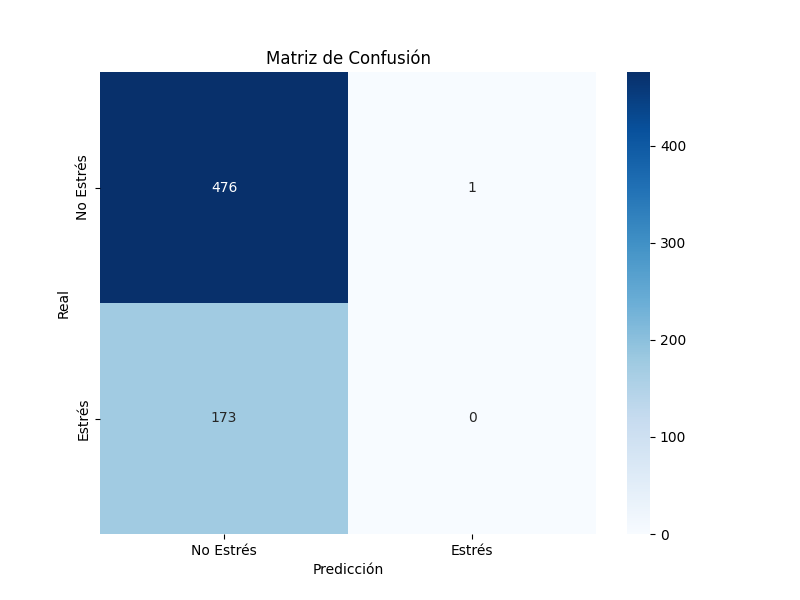

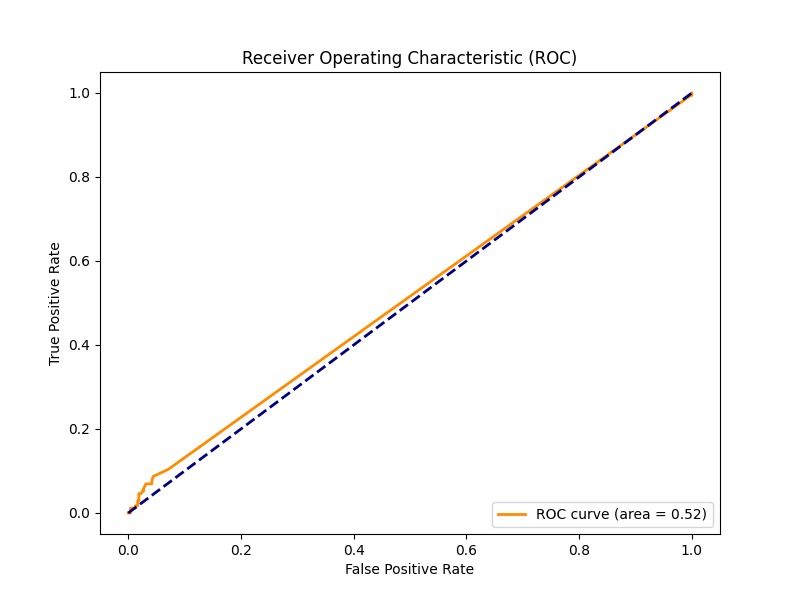

In [4]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.3_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--audio wav2vec "
        f"--audio_len 7 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_AUDIO_wav2vec_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_AUDIO_wav2vec_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **RoBERTa**:
    * **Ventana**: 64 tokens
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 512, `hidden_mlp` = 128
        * **Dropout**: 0.3
        * **Learning Rate**: 5e-05

100%|██████████| 650/650 [00:00<00:00, 960.37it/s] 


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 460,801
Parámetros Entrenables: 460,801
Tiempo medio de Inferencia: 0.30 ms / muestra
ROC-AUC Score: 0.5193
F1 Macro: 0.5152
F1 Weighted: 0.6198
Accuracy (en %): 61.85%
Balanced Accuracy (en %): 51.53%


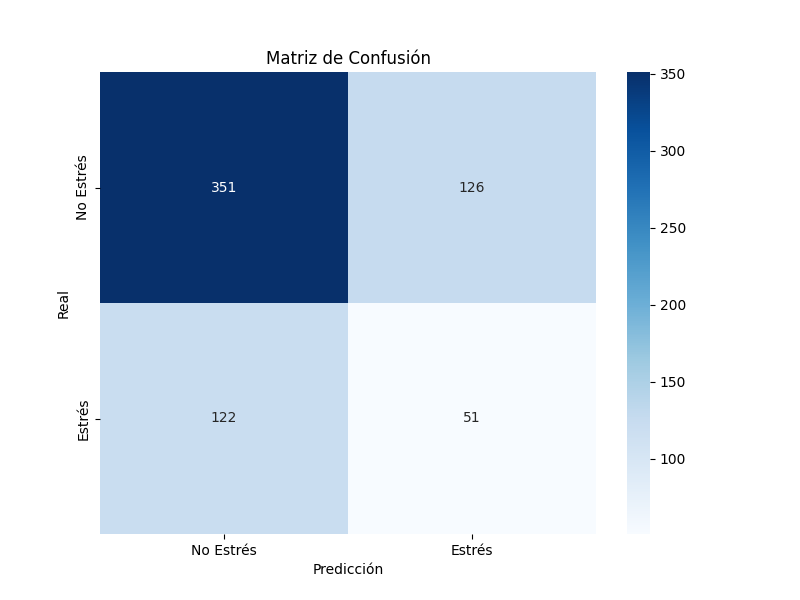

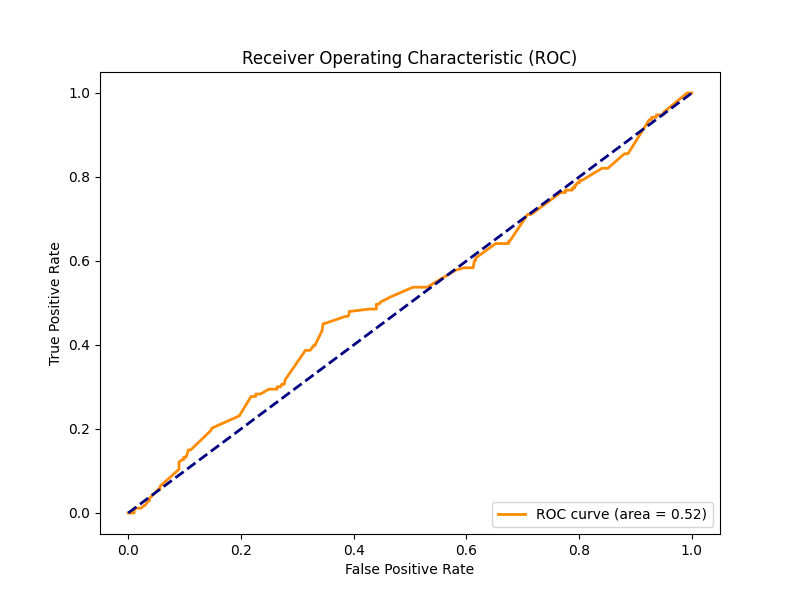

In [5]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.3_lr5e-05.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--text roberta64 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_TEXTO_roberta64_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_TEXTO_roberta64_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

### **2. Baselines Bimodales**

* **Vídeo + Audio**:

100%|██████████| 650/650 [00:03<00:00, 170.41it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,530,565
Parámetros Entrenables: 6,530,565
Tiempo medio de Inferencia: 4.27 ms / muestra
ROC-AUC Score: 0.5825
F1 Macro: 0.4354
F1 Weighted: 0.6284
Accuracy (en %): 73.69%
Balanced Accuracy (en %): 50.58%


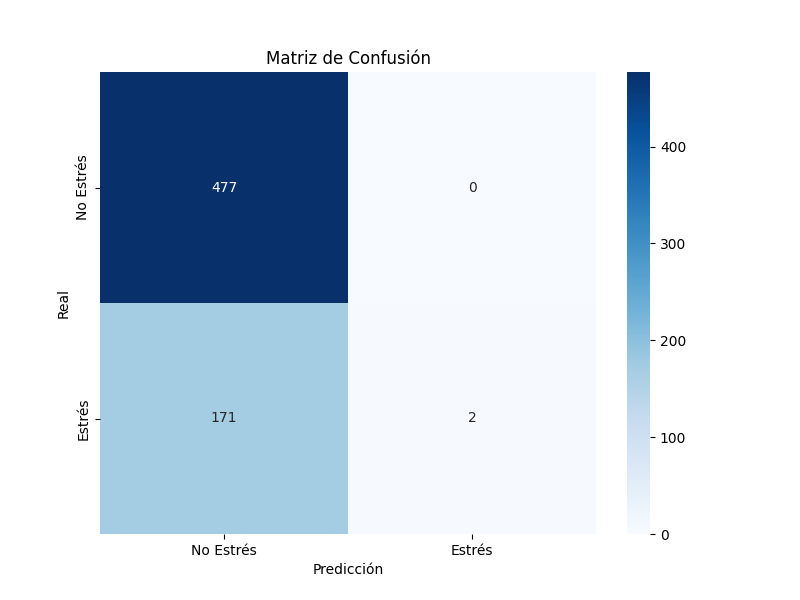

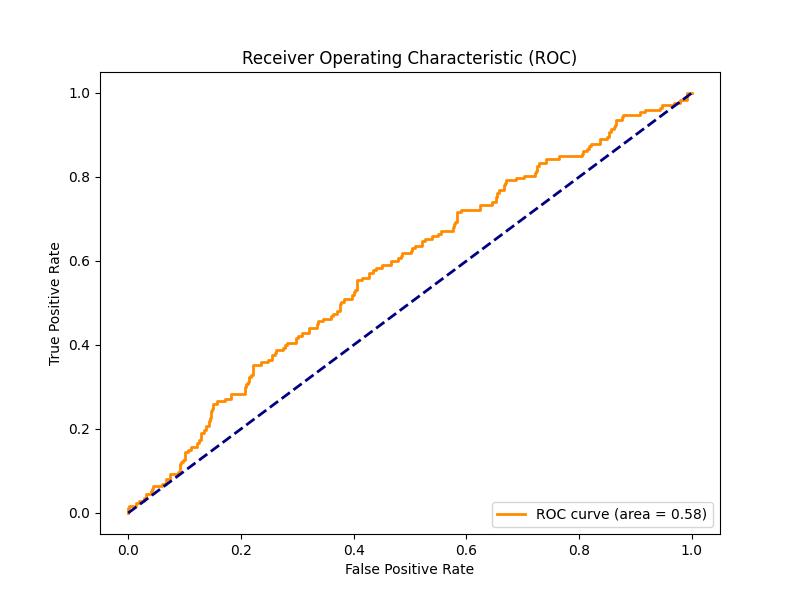

In [6]:
path_pesos = "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--fusion late "
        f"--late_mode logistica "
        f"--video resnet "
        f"--audio wav2vec "
        f"--proj_dim 256 "
        f"--hidden_mlp 64 "
        f"--dropout 0.3 "
        f"--video_frames 16 "
        f"--audio_len 7 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Vídeo + Texto**:

100%|██████████| 650/650 [00:01<00:00, 612.17it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,038,533
Parámetros Entrenables: 6,038,533
Tiempo medio de Inferencia: 0.90 ms / muestra
ROC-AUC Score: 0.4658
F1 Macro: 0.4341
F1 Weighted: 0.6222
Accuracy (en %): 72.00%
Balanced Accuracy (en %): 49.61%


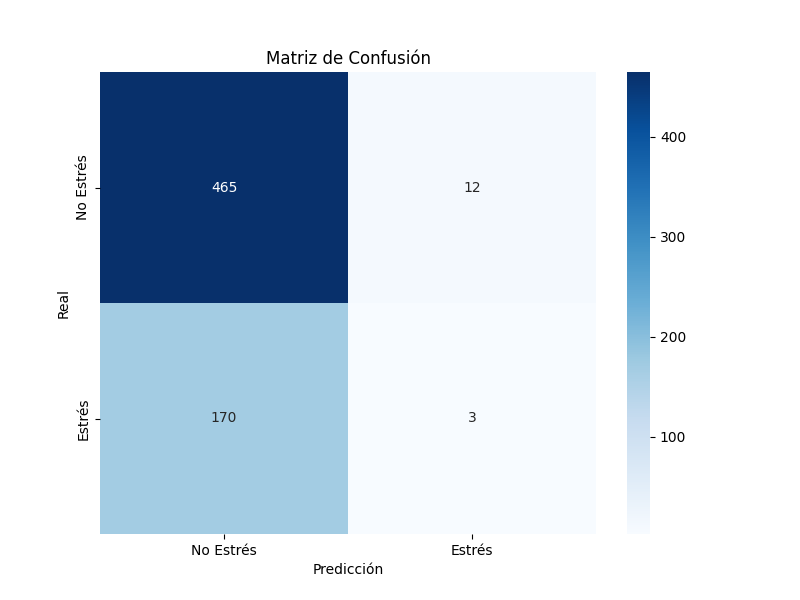

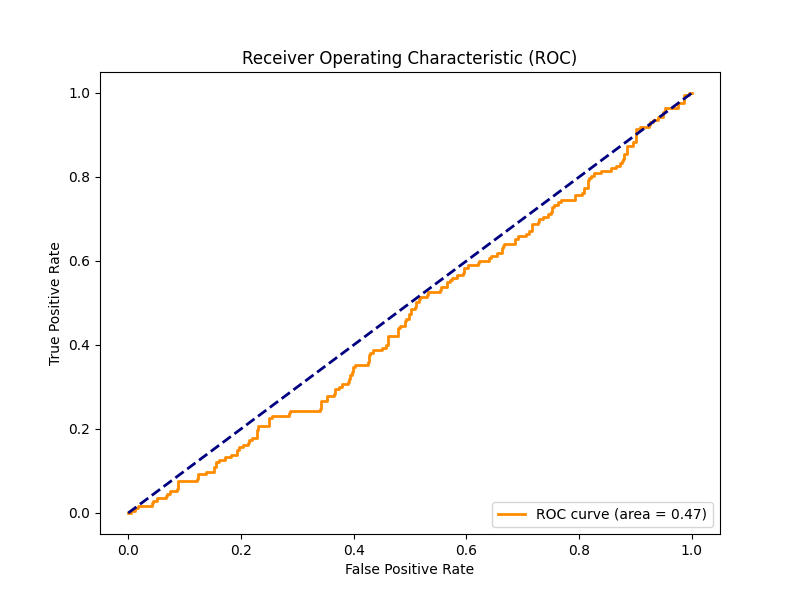

In [7]:
path_pesos = "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--fusion late "
        f"--late_mode logistica "
        f"--video resnet "
        f"--text roberta64 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.5 "
        f"--video_frames 32 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Audio + Texto**:

100%|██████████| 650/650 [00:03<00:00, 192.53it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 3,417,090
Parámetros Entrenables: 3,417,090
Tiempo medio de Inferencia: 3.95 ms / muestra
ROC-AUC Score: 0.5511
F1 Macro: 0.4931
F1 Weighted: 0.6321
Accuracy (en %): 62.62%
Balanced Accuracy (en %): 49.33%


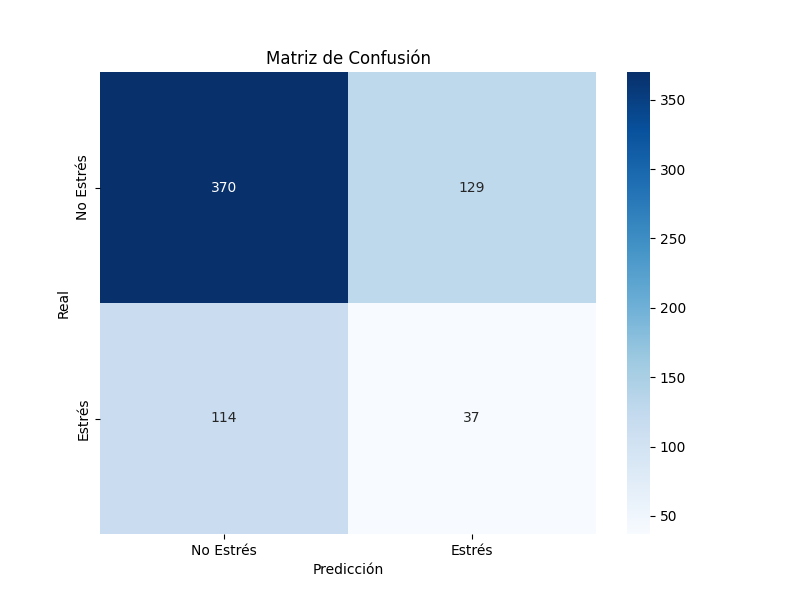

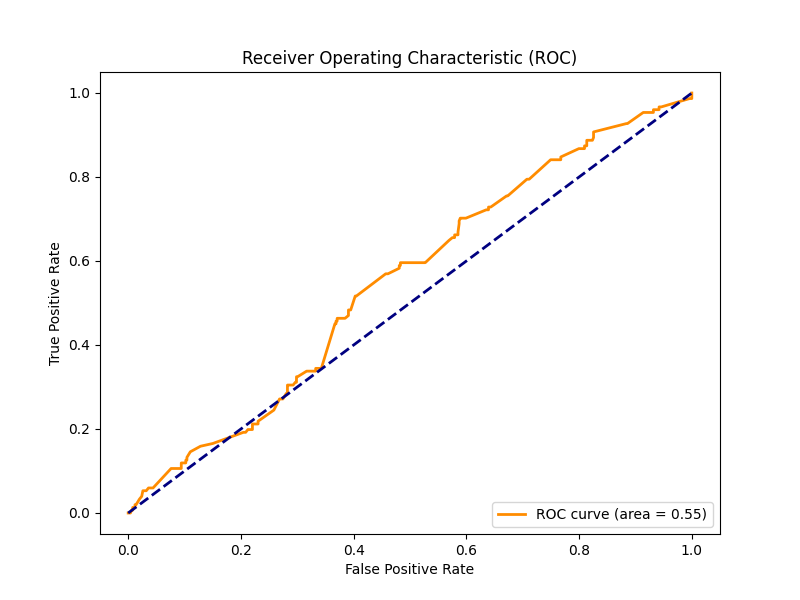

In [11]:
path_pesos = "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--fusion late "
        f"--late_mode promedio "
        f"--text roberta64 "
        f"--audio wav2vec "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
        f"--audio_len 7 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

### **3. Modelos Intra-dominio**

* **Modelo entrenado en MELD**: 

100%|██████████| 650/650 [00:03<00:00, 199.95it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.53 ms / muestra
ROC-AUC Score: 0.5686
F1 Macro: 0.5205
F1 Weighted: 0.6571
Accuracy (en %): 69.85%
Balanced Accuracy (en %): 52.93%


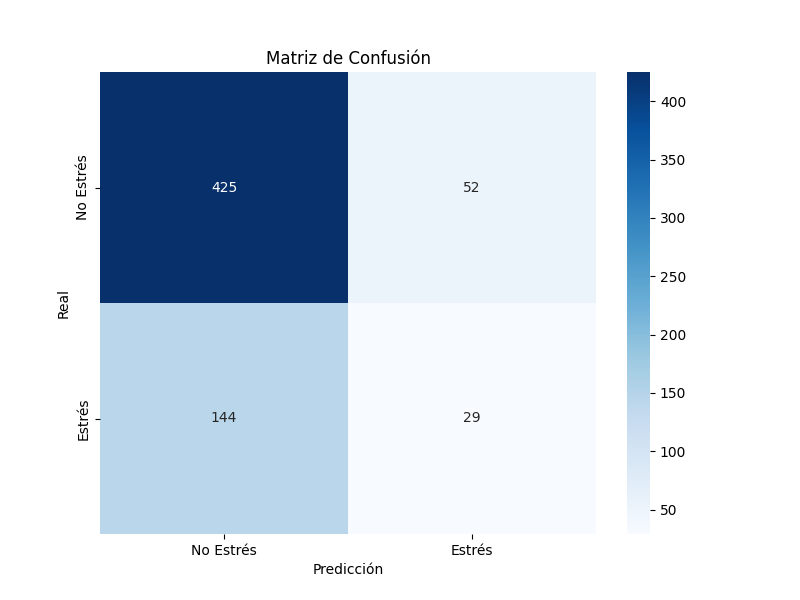

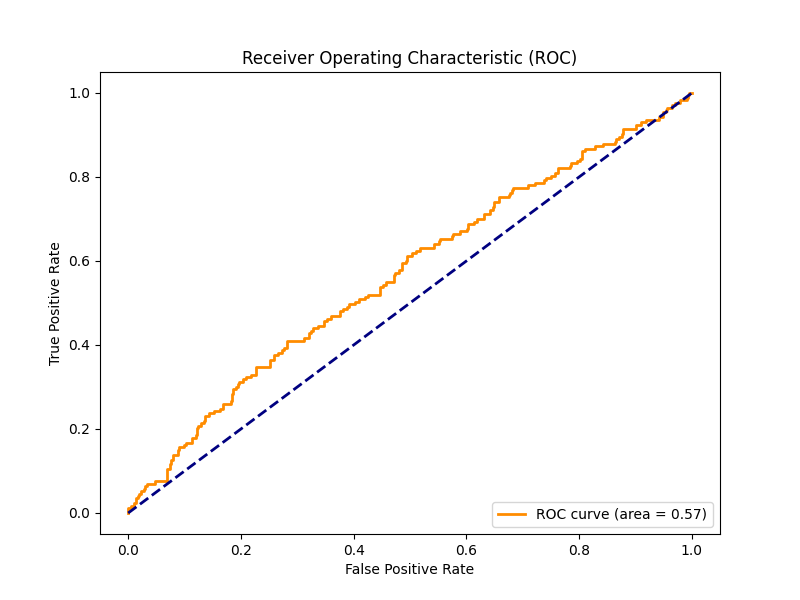

In [8]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
          f"--transfer_learning MSP-IMPROV ") ###
                        
subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Modelo entrenado en IEMOCAP**: 

100%|██████████| 650/650 [00:02<00:00, 217.13it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.41 ms / muestra
ROC-AUC Score: 0.4829
F1 Macro: 0.3627
F1 Weighted: 0.3554
Accuracy (en %): 36.31%
Balanced Accuracy (en %): 47.95%


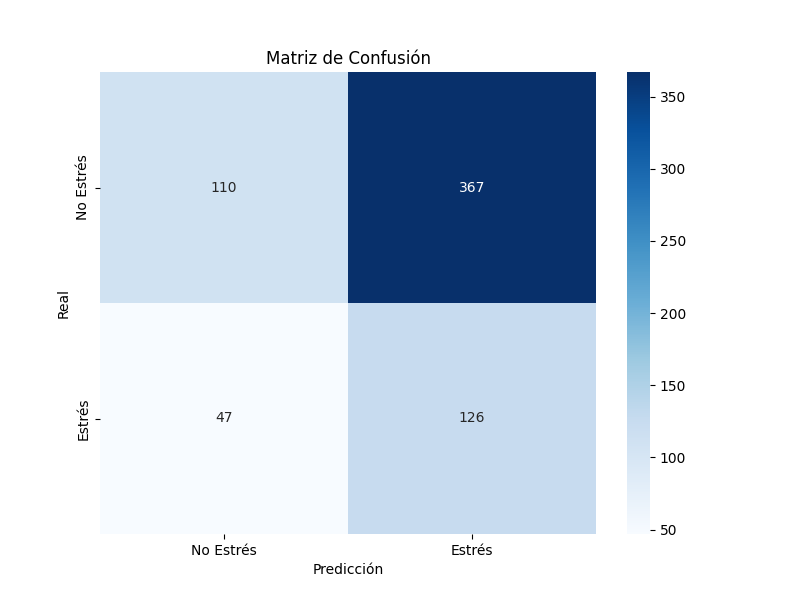

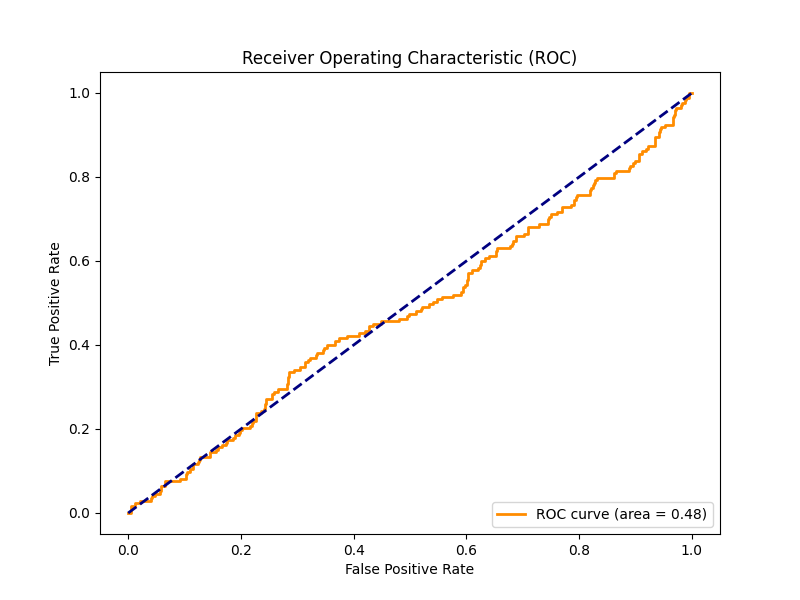

In [9]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
          f"--transfer_learning MSP-IMPROV ") ###
                        
subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

Figura y tabla comparativa de modelos intra-dominio sobre MSP-IMPROV y de forma cruzada:

,Modelo Entrenado,Test MELD,Test IEMOCAP,Test MSP-IMPROV
0,Intra-dominio (Solo MELD),0.6664,0.5158,0.5205
1,Intra-dominio (Solo IEMOCAP),0.5268,0.6860,0.3627


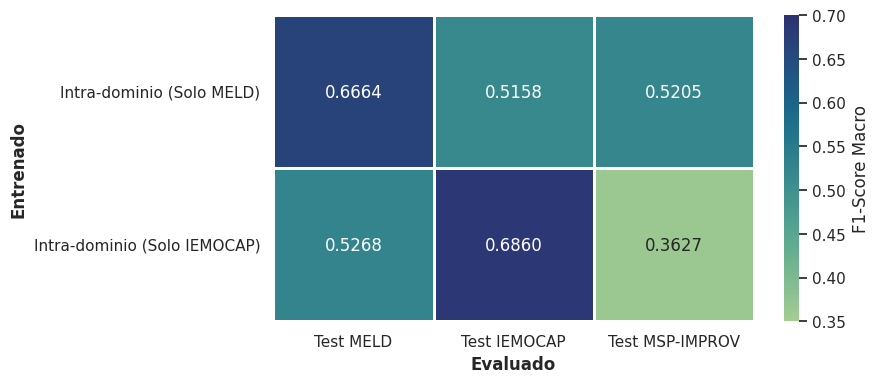

In [10]:
datos_transfer = {
    'Modelo Entrenado': ['Intra-dominio (Solo MELD)', 'Intra-dominio (Solo IEMOCAP)'],
    'Test MELD': [0.6664, 0.5268],                
    'Test IEMOCAP': [0.5158, 0.6860],             
    'Test MSP-IMPROV': [0.5205, 0.3627] 
}

df_transfer = pd.DataFrame(datos_transfer)


df_transfer.to_csv('tabla_transfer_intradominio.csv', index=False)
display(df_transfer.style.background_gradient(cmap='Blues', axis=1).format(precision=4))

df_heatmap = df_transfer.set_index('Modelo Entrenado')

plt.figure(figsize=(9, 4))
sns.set_theme(style="white")

mapa = sns.heatmap(
    df_heatmap, 
    annot=True,          
    fmt=".4f",           
    cmap="crest",        
    vmin=0.35, vmax=0.70, 
    linewidths=1,        
    cbar_kws={'label': 'F1-Score Macro'}
)

plt.ylabel('Entrenado', fontsize=12, fontweight='bold')
plt.xlabel('Evaluado', fontsize=12, fontweight='bold')

plt.yticks(rotation=0, fontsize=11)
plt.xticks(fontsize=11)

plt.tight_layout()
plt.savefig('Fig_heatmap_transfer_intradominio.png', dpi=300, bbox_inches='tight')
plt.show()

Se observa que el rendimiento cae cuando los modelos intra-dominio son evaluados en datasets distintos, ya sea de forma cruzada o con MSP-IMPROV, siendo este último en el que peor rinde el modelo de IEMOCAP.

### **4. Arquitectura mutlimodal entrenada sobre Corpus Global (Modelo Final)**

* **Corpus Global Unificado (MELD + IEMOCAP)**: 
    * Arquitectura de Fusión mediante Atención:
        - **Ventana de Vídeo**: 32 frames
        - **Ventana de Audio**: 7 segundos
        - **Ventana de Texto**: 32 tokens
        - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
        - **Learning Rate**: 5e-05
        - **Dropout**: 0.3

100%|██████████| 650/650 [00:03<00:00, 210.29it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.58 ms / muestra
ROC-AUC Score: 0.5257
F1 Macro: 0.5258
F1 Weighted: 0.6108
Accuracy (en %): 59.54%
Balanced Accuracy (en %): 53.28%


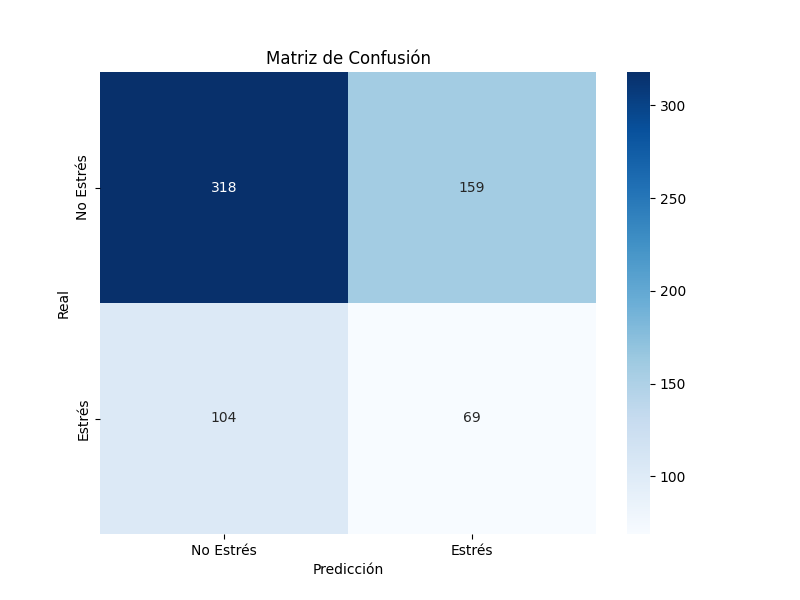

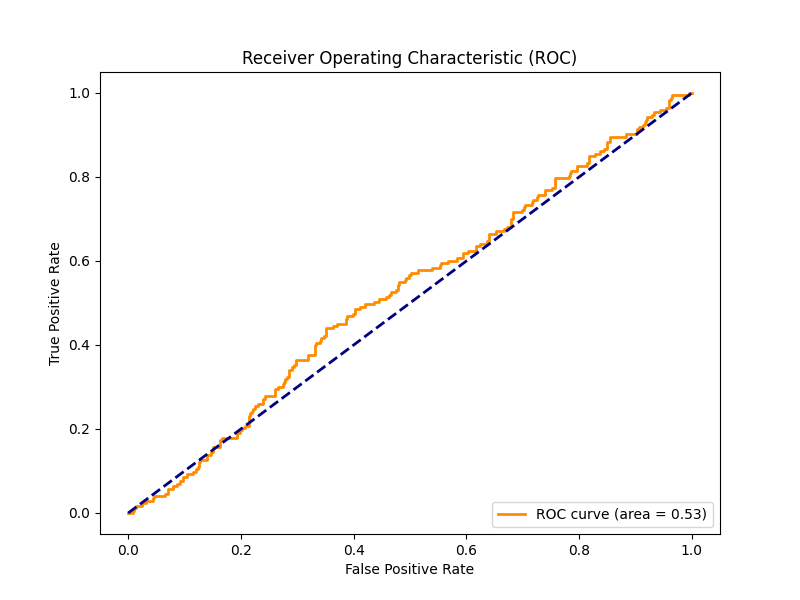

In [11]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning MSP-IMPROV ") ####
                        
subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"

display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

------
## **Figura Comparativa Final Resultados en MSP-IMPROV**

,Modelo,F1-Macro,Balanced Accuracy,ROC-AUC,Recall (Estrés)
0,Global Final,0.5258,0.5328,0.5257,0.3988
1,Intra MELD,0.5205,0.5293,0.5686,0.1676
2,Unimodal Texto (RoBERTa),0.5152,0.5153,0.5193,0.2948
3,Bimodal Audio y Texto,0.4931,0.4933,0.5511,0.2450
4,Unimodal Vídeo (ResNet),0.4367,0.4882,0.5795,0.0289
5,Bimodal Vídeo y Audio,0.4354,0.5058,0.5825,0.0116
6,Bimodal Vídeo y Texto,0.4341,0.4961,0.4658,0.0173
7,Unimodal Audio (Wav2Vec),0.4227,0.4990,0.5153,0.0000
8,Intra IEMOCAP,0.3627,0.4795,0.4829,0.7283


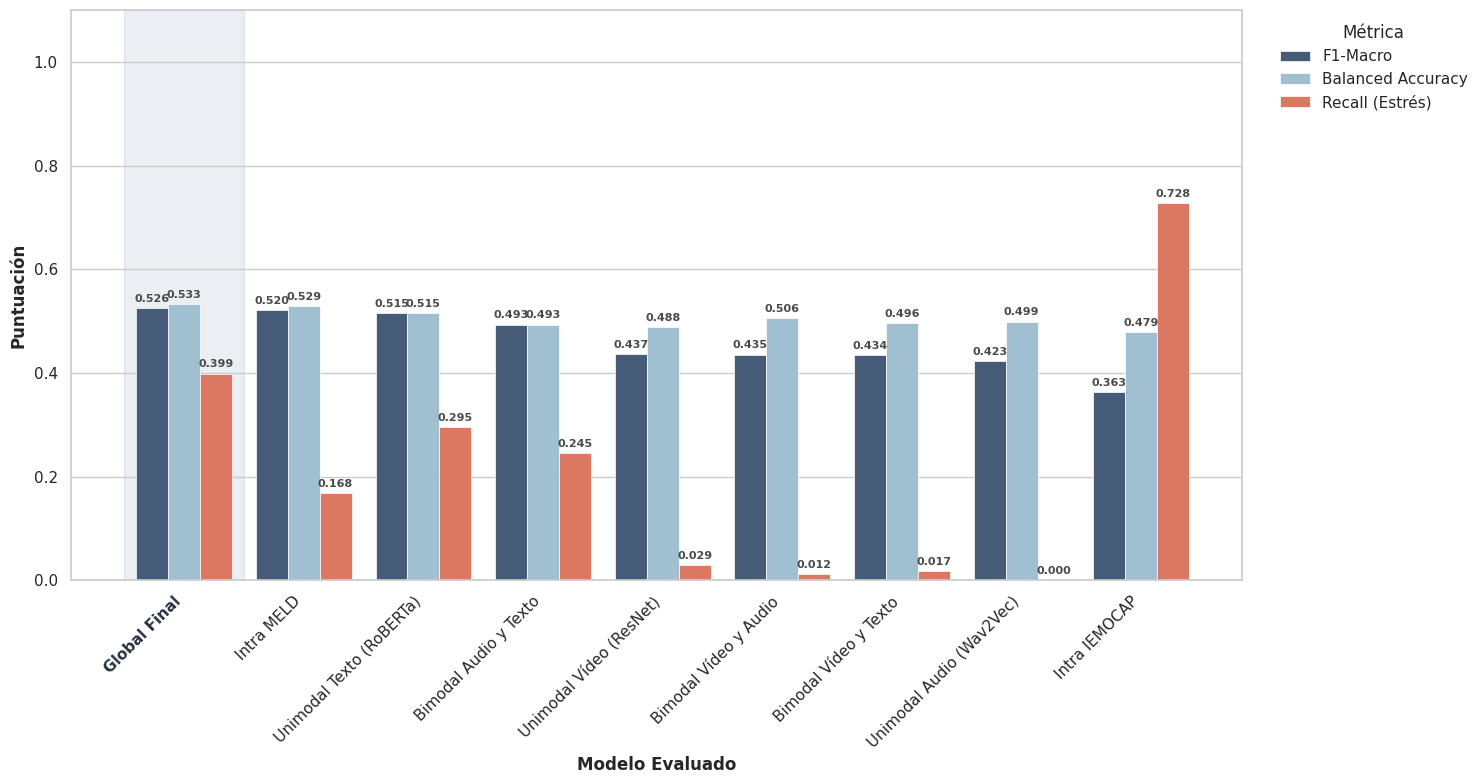

In [12]:
archivos_modelos = {
    'Unimodal Vídeo (ResNet)': 'resultados/transfer_learning/unimodales/reporte_final_baseline_unimodal_VIDEO_resnet_transfer_learning_MSP-IMPROV.txt',
    'Unimodal Audio (Wav2Vec)': 'resultados/transfer_learning/unimodales/reporte_final_baseline_unimodal_AUDIO_wav2vec_transfer_learning_MSP-IMPROV.txt',
    'Unimodal Texto (RoBERTa)': 'resultados/transfer_learning/unimodales/reporte_final_baseline_unimodal_TEXTO_roberta64_transfer_learning_MSP-IMPROV.txt',
    'Bimodal Vídeo y Audio': 'resultados/transfer_learning/bimodales/reporte_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Bimodal Vídeo y Texto': 'resultados/transfer_learning/bimodales/reporte_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.txt',
    'Bimodal Audio y Texto': 'resultados/transfer_learning/bimodales/reporte_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Intra MELD': 'resultados/transfer_learning/intra/MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.txt',
    'Intra IEMOCAP': 'resultados/transfer_learning/intra/IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Global Final': 'resultados/transfer_learning/inter_multimodal/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.txt'
}

datos_msp = []
for modelo, ruta in archivos_modelos.items():
    f1, ba, auc, recall = extraer_metricas_txt(ruta)
    datos_msp.append([modelo, f1, ba, auc, recall])


columnas = ['Modelo', 'F1-Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']
df_msp = pd.DataFrame(datos_msp, columns=columnas)

# Ordenamos por F1-Macro
df_msp = df_msp.sort_values(by='F1-Macro', ascending=False).reset_index(drop=True)

df_msp.to_csv('tabla_resultados_MSP_IMPROV_completa.csv', index=False)
display(df_msp.style.background_gradient(cmap='Blues', subset=['F1-Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']).format(precision=4))


# Filtramos solo las métricas de F1-Macro y Balanced Accuracy
df_grafica = df_msp[['Modelo', 'F1-Macro', 'Balanced Accuracy', 'Recall (Estrés)']]
df_melted = df_grafica.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

colores_elegantes = ['#3D5A80', '#98C1D9', '#EE6C4D'] 

ax = sns.barplot(
    data=df_melted, 
    x='Modelo', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores_elegantes,
    edgecolor='white', 
    linewidth=0.5
)

etiquetas_x = [t.get_text() for t in ax.get_xticklabels()]
if 'Global Final' in etiquetas_x:
    idx_final = etiquetas_x.index('Global Final')

    ax.axvspan(idx_final - 0.5, idx_final + 0.5, color='#3D5A80', alpha=0.10, zorder=0)

    for tick in ax.get_xticklabels():
        if tick.get_text() == 'Global Final':
            tick.set_fontweight('bold')
            tick.set_color('#293241') 

plt.ylim(0, 1.1) 
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('Modelo Evaluado', fontsize=12, fontweight='bold')

# Rotación para legibilidad:
plt.xticks(rotation=45, ha='right', fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8, color='#4a4a4a', fontweight='bold')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False) 

plt.tight_layout()
nombre_grafica = 'Fig_Resultados_MSP_IMPROV_Ordenada.png'
plt.savefig(nombre_grafica, dpi=300, bbox_inches='tight')

plt.show()

Claramente, todas las métricas se desploman en comparación con test del dataset correspondiente, indicando que la naturaleza de este corpus es diferente a MELD e IEMOCAP, presentando el modelo mayores dificultades para la tarea. En la gráfica, se observa ordenada por F1-Score Macro, siendo el mejor modelo el global final multimodal entrenado sobre MELD e IEMOCAP, confirmándose que se beneficia, no solo de la multimodalidad, sino del multidominio, para alcanzar una mayor capacidad de generalización.

------
## **Evaluación cruzada entre dominios de la arquitectura multimodal final**

Entrenamos rotando los diferentes corpus de entrenamiento, y evaluamos con el dataset faltante no visto por el modelo durante su entrenamiento. Tras obtener los resultados en evaluación de transferencia de aprendizaje en cada iteración, reportamos finalmente el promedio para obtener la capacidad real de generalización y transferencia de conocimiento de la arquitectura multimodal final. 

1. **Entrenamiento: MSP-IMPROV y MELD**

In [13]:
comando = (f"python train.py "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--lr 5e-05 "
           f"--dropout 0.3 "
           f"--transfer_learning MELD_MSP-IMPROV ")
                        
subprocess.run(comando, shell=True)

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 325/325 [00:27<00:00, 11.67it/s, loss=0.611]


Epoch 1. Train Loss: 1.1006. Val Loss: 1.1541. Val F1 Macro: 0.6116. Val Recall Estrés: 0.6680

Nuevo mejor modelo: (F1: 0.6116) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 325/325 [00:19<00:00, 16.96it/s, loss=1.17] 


Epoch 2. Train Loss: 0.9691. Val Loss: 1.1207. Val F1 Macro: 0.5999. Val Recall Estrés: 0.7640

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 14/20: 100%|██████████| 325/325 [00:17<00:00, 18.42it/s, loss=0.697]


Epoch 14. Train Loss: 0.4002. Val Loss: 1.4243. Val F1 Macro: 0.6087. Val Recall Estrés: 0.6840

Sin mejora en F1-Score. Límite: 4/5


Epoch 15/20: 100%|██████████| 325/325 [00:17<00:00, 18.10it/s, loss=0.558]


Epoch 15. Train Loss: 0.3613. Val Loss: 1.6035. Val F1 Macro: 0.6250. Val Recall Estrés: 0.4920

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 15 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.json


CompletedProcess(args='python train.py --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --lr 5e-05 --dropout 0.3 --transfer_learning MELD_MSP-IMPROV ', returncode=0)

Lo evaluamos en IEMOCAP: 

In [14]:
path_pesos = "pesos/transfer_learning/pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning IEMOCAP ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 7515/7515 [00:42<00:00, 175.09it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.48 ms / muestra
ROC-AUC Score: 0.6510
F1 Macro: 0.5024
F1 Weighted: 0.5555
Accuracy (en %): 63.74%
Balanced Accuracy (en %): 55.40%


CompletedProcess(args='python evaluate.py --model_path pesos/transfer_learning/pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --transfer_learning IEMOCAP ', returncode=0)

2. **Entrenamiento: MSP-IMPROV e IEMOCAP**

In [15]:
comando = (f"python train.py "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--lr 5e-05 "
           f"--dropout 0.3 "
           f"--transfer_learning IEMOCAP_MSP-IMPROV ")
                        
subprocess.run(comando, shell=True)

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 154/154 [00:08<00:00, 18.76it/s, loss=0.704]


Epoch 1. Train Loss: 0.7404. Val Loss: 0.7306. Val F1 Macro: 0.5868. Val Recall Estrés: 0.6072

Nuevo mejor modelo: (F1: 0.5868) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 154/154 [00:08<00:00, 18.41it/s, loss=0.468]


Epoch 2. Train Loss: 0.6305. Val Loss: 0.6776. Val F1 Macro: 0.6433. Val Recall Estrés: 0.6110

Nuevo mejor modelo: (F1: 0.6433) -> Guardando pesos...


...

Epoch 15/20: 100%|██████████| 154/154 [00:07<00:00, 19.51it/s, loss=0.168]


Epoch 15. Train Loss: 0.2890. Val Loss: 0.6868. Val F1 Macro: 0.6920. Val Recall Estrés: 0.5313

Sin mejora en F1-Score. Límite: 4/5


Epoch 16/20: 100%|██████████| 154/154 [00:08<00:00, 17.85it/s, loss=0.387]


Epoch 16. Train Loss: 0.2825. Val Loss: 0.8290. Val F1 Macro: 0.6425. Val Recall Estrés: 0.6053

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 16 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.json


CompletedProcess(args='python train.py --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --lr 5e-05 --dropout 0.3 --transfer_learning IEMOCAP_MSP-IMPROV ', returncode=0)

Evaluamos con MELD:

In [16]:
path_pesos = "pesos/transfer_learning/pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning MELD ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 13704/13704 [01:04<00:00, 212.45it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.42 ms / muestra
ROC-AUC Score: 0.6440
F1 Macro: 0.5798
F1 Weighted: 0.7653
Accuracy (en %): 74.07%
Balanced Accuracy (en %): 60.93%


CompletedProcess(args='python evaluate.py --model_path pesos/transfer_learning/pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --transfer_learning MELD ', returncode=0)

3. **Entrenamiento: MELD e IEMOCAP y Evaluación con MSP-IMPROV**: Ya realizado. 

Reportamos finalmente el promedio y resultados obtenidos por cada iteración:

,Corpus Excluido (Test),F1-Macro,Balanced Accuracy,ROC-AUC,Recall (Estrés)
0,Test en MSP-IMPROV,0.5258,0.5328,0.5257,0.3988
1,Test en IEMOCAP,0.5024,0.5540,0.6510,0.1466
2,Test en MELD,0.5798,0.6093,0.6440,0.4249
3,PROMEDIO GLOBAL,0.5360,0.5654,0.6069,0.3234


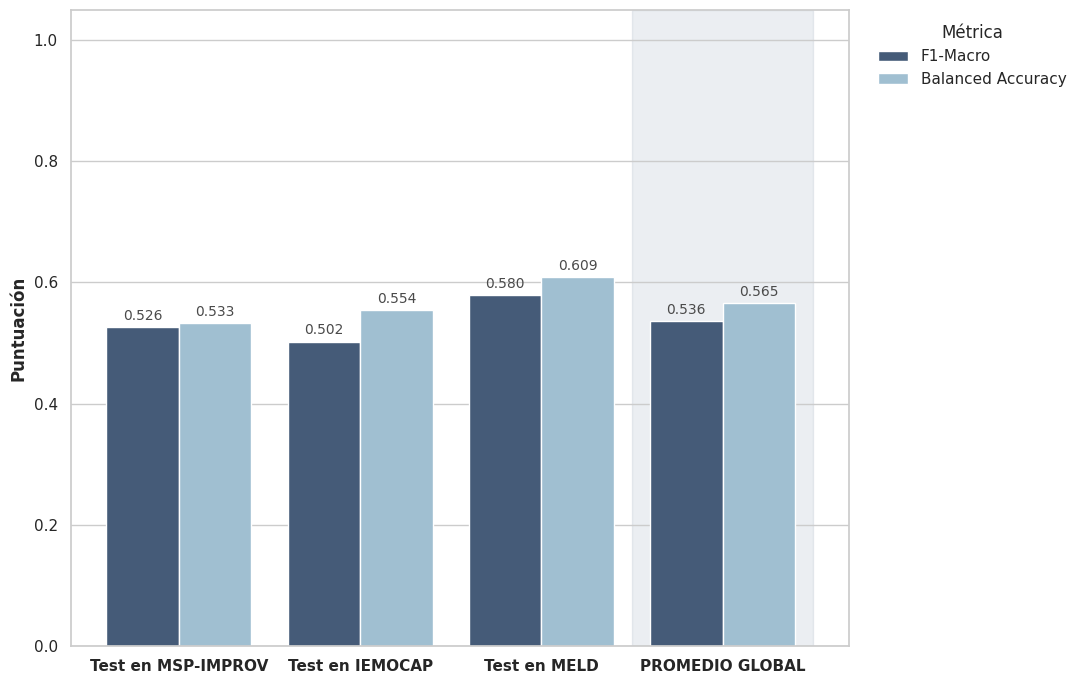

In [17]:
archivos_reportes = {
    'Test en MSP-IMPROV': 'resultados/transfer_learning/inter_multimodal/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Test en IEMOCAP': 'resultados/transfer_learning/inter_rotacion/reporte_pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_IEMOCAP.txt',
    'Test en MELD': 'resultados/transfer_learning/inter_rotacion/reporte_pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MELD.txt'
}

datos_rotacion = []
for nombre_eval, ruta in archivos_reportes.items():
    f1, ba, auc, recall = extraer_metricas_txt(ruta)
    datos_rotacion.append([nombre_eval, f1, ba, auc, recall])

columnas = ['Corpus Excluido (Test)', 'F1-Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']
df_rotacion = pd.DataFrame(datos_rotacion, columns=columnas)

# Calculamos el promedio:
promedios = df_rotacion.mean(numeric_only=True)
fila_promedio = pd.DataFrame([['PROMEDIO GLOBAL', promedios['F1-Macro'], promedios['Balanced Accuracy'], promedios['ROC-AUC'], promedios['Recall (Estrés)']]], columns=columnas)

df_final = pd.concat([df_rotacion, fila_promedio], ignore_index=True)

df_final.to_csv('tabla_evaluacion_cruzada_automatica.csv', index=False)

def resaltar_promedio(row):
    if row['Corpus Excluido (Test)'] == 'PROMEDIO GLOBAL':
        return ['background-color: #dbeafe; font-weight: bold'] * len(row)
    return [''] * len(row)

display(df_final.style.apply(resaltar_promedio, axis=1).format(precision=4))

# ---------------------- GRÁFICA ----------------------------
df_grafica = df_final[['Corpus Excluido (Test)', 'F1-Macro', 'Balanced Accuracy']]
df_melted = df_grafica.melt(id_vars='Corpus Excluido (Test)', var_name='Métrica', value_name='Puntuación')

plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

colores = ['#3D5A80', '#98C1D9'] 

ax = sns.barplot(
    data=df_melted, 
    x='Corpus Excluido (Test)', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores,
    edgecolor='white',
    linewidth=1
)

etiquetas_x = [t.get_text() for t in ax.get_xticklabels()]
if 'PROMEDIO GLOBAL' in etiquetas_x:
    idx_final = etiquetas_x.index('PROMEDIO GLOBAL')
    ax.axvspan(idx_final - 0.5, idx_final + 0.5, color='#3D5A80', alpha=0.10, zorder=0)

plt.ylim(0, 1.05)
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('', fontsize=12)

plt.xticks(fontsize=11, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, color='#4a4a4a')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False) 
plt.tight_layout()

plt.savefig('Fig_Resultados_rotacion_Transferencia_Aprendizaje.png', dpi=300, bbox_inches='tight')
plt.show()

Se mantienen valores similares en cada una de las iteraciones, destacando el valor más bajo cuando en test tenemos a IEMOCAP. 